In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
from scipy.integrate import quad

In [2]:
def mad_by_group(df, value_col, group_col, threshold=3.5):
    def remove_group_outliers(group):
        median = group[value_col].median()
        mad = np.median(np.abs(group[value_col] - median))

        # Avoid division by zero
        if mad == 0:
            return group

        modified_z = 0.6745 * (group[value_col] - median) / mad
        return group[np.abs(modified_z) <= threshold]

    return df.groupby(group_col, group_keys=False).apply(remove_group_outliers)

In [3]:
#
#           LOAD DATASETS:
#

df_gk_model_combined = pd.read_csv('experimental_data/gk_model_data_new.csv')
print(len(df_gk_model_combined[df_gk_model_combined['source'] == 'model']))
df_gk_model_combined = mad_by_group(df_gk_model_combined, value_col="time", group_col="subject_num")    # remove extreme outliers
print(len(df_gk_model_combined[df_gk_model_combined['source'] == 'model']))

df_just_gk = df_gk_model_combined[df_gk_model_combined['source'] == 'gk']
df_just_model_gk = df_gk_model_combined[df_gk_model_combined['source'] == 'model']

df_jj_model_combined = pd.read_csv('experimental_data/jj_model_data_new.csv')
# print(len(df_jj_model_combined[df_jj_model_combined['source'] == 'jj']))
print(len(df_jj_model_combined[df_jj_model_combined['source'] == 'model']))
df_jj_model_combined = mad_by_group(df_jj_model_combined, value_col="time", group_col="subject_num")    # remove extreme outliers
# print(len(df_jj_model_combined[df_jj_model_combined['source'] == 'jj']))
print(len(df_jj_model_combined[df_jj_model_combined['source'] == 'model']))

df_just_jj = df_jj_model_combined[df_jj_model_combined['source'] == 'jj']
df_just_model_jj = df_jj_model_combined[df_jj_model_combined['source'] == 'model']

# create dataset copies for graphing
df_gk_model_combined_graphing = df_gk_model_combined.copy()
df_gk_model_combined_graphing['source'] = df_gk_model_combined_graphing['source'].map({
    "gk": "Ganis-Kievet",
    "model": "Model"
})
# df_gk_model_combined_graphing['correct'] = df_gk_model_combined_graphing['correct'].map({
#     0: "Incorrect",
#     1: "Correct"
# })
df_jj_model_combined_graphing = df_jj_model_combined.copy()
df_jj_model_combined_graphing['source'] = df_jj_model_combined_graphing['source'].map({
    "jj": "Jost-Jansen",
    "model": "Model"
})
# df_jj_model_combined_graphing['correct'] = df_jj_model_combined_graphing['correct'].map({
#     0: "Incorrect",
#     1: "Correct"
# })


4800
4743
17920
17715


Model mean RT: 2.64853320683112 s
Model sd: 1.0556199280122964 s
Ganis+Kievet mean RT: 2.6840483197454765 s
Ganis+Kievet sd: 1.3796982721045172 s


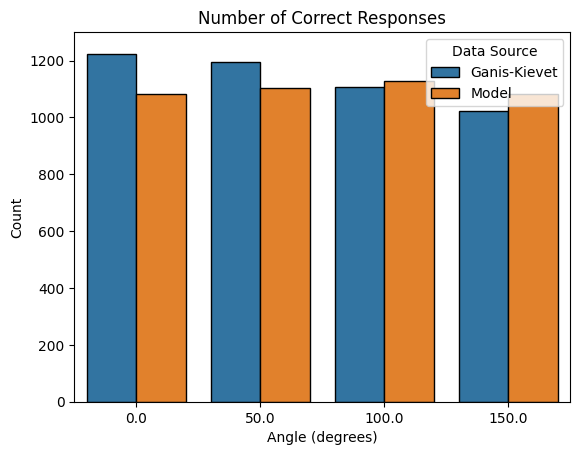

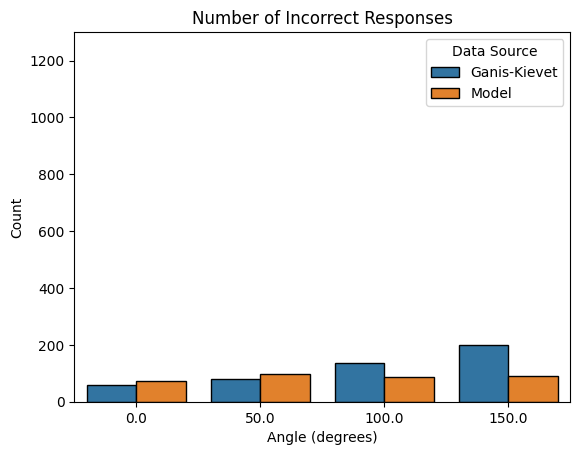

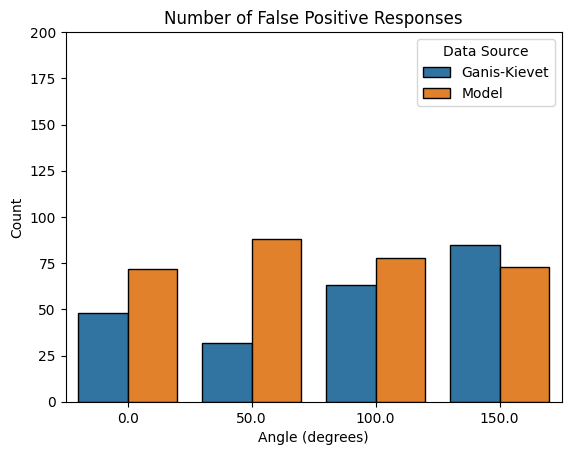

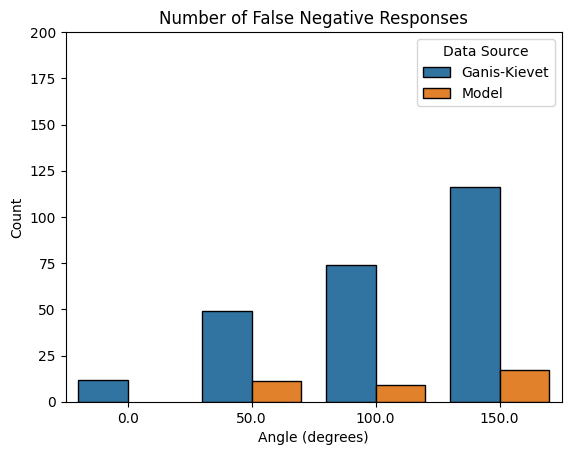


Model incorrect: 348
Model incorrect % : 0.07337128399746995
GK incorrect: 479
GK incorrect % : 0.09524756412805727

Model false positives: 311
Model false positives %: 0.8936781609195402
Model total trials: 4743

Ganis+Kievet false positives: 228
Ganis+Kievet false positives %: 0.4759916492693111
GK total trials: 5029
Model false negatives: 37
Ganis+Kievet false negatives: 251


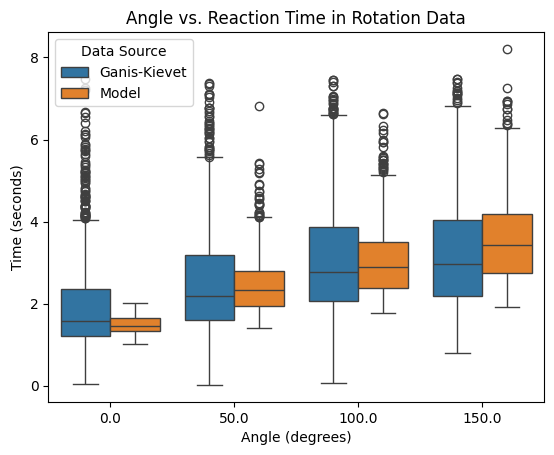

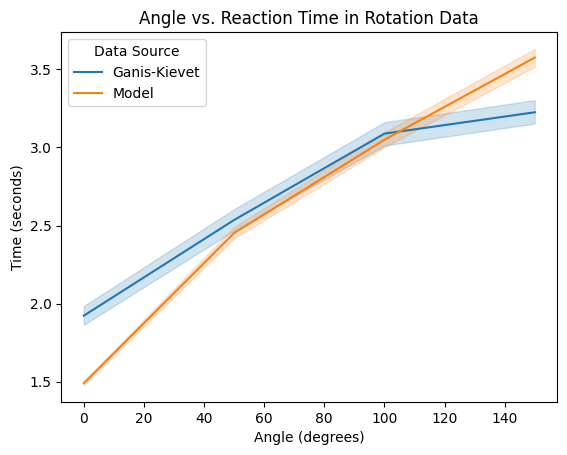

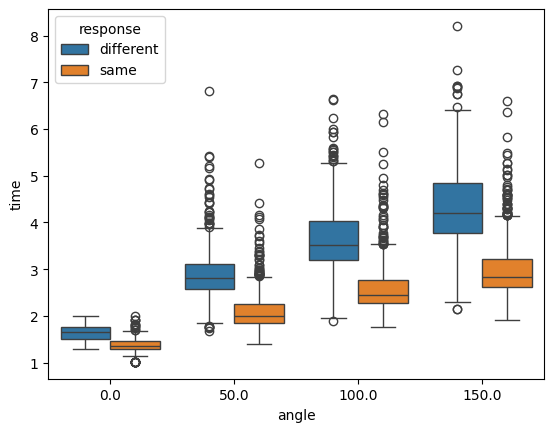

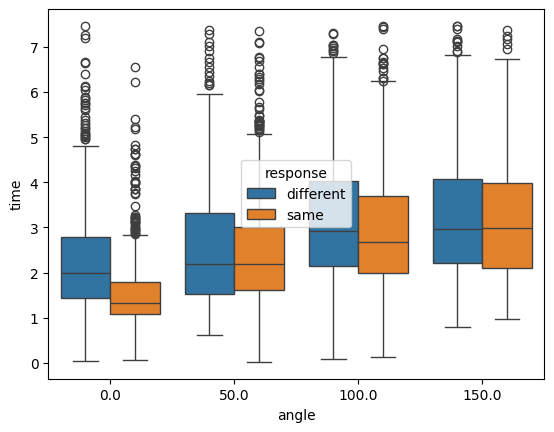


Model angle slope + intercept: 73.0040206495049 deg/s, with intercept of 1.6163550974189405 s
Ganis+Kievet angle slope + intercept: 111.70684736813683 deg/s, with intercept of 2.0217710067529406 s

RMSE: 0.2823226429702553 s
MAE: 0.2265906756372113 s
R squared: 0.9581280505236093

PearsonRResult(statistic=0.9884758092807683, pvalue=0.011524190719231608)
                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           time       
No. Observations:             9772              Method:                       REML       
No. Groups:                   104               Scale:                        0.7068     
Min. group size:              85                Log-Likelihood:               -12408.2435
Max. group size:              96                Converged:                    Yes        
Mean group size:              94.0                                                       
---------------------------------------

In [10]:
#
#           Ganis + Kievet Analysis
#

# mean + error count
mean_just_model_gk = df_just_model_gk['time'].mean()
sd_just_model_gk = df_just_model_gk['time'].std()
mean_gk = df_just_gk['time'].mean()
sd_gk = df_just_gk['time'].std()

print("Model mean RT: " + str(mean_just_model_gk) + " s")
print("Model sd: " + str(sd_just_model_gk) + " s")
print("Ganis+Kievet mean RT: " + str(mean_gk) + " s")
print("Ganis+Kievet sd: " + str(sd_gk) + " s")



sns.countplot(data=df_gk_model_combined_graphing[df_gk_model_combined_graphing['correct'] == 1], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of Correct Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,1300)
plt.show()

sns.countplot(data=df_gk_model_combined_graphing[df_gk_model_combined_graphing['correct'] == 0], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of Incorrect Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,1300)
plt.show()

sns.countplot(data=df_gk_model_combined_graphing[df_gk_model_combined_graphing['false_positive'] == 1], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of False Positive Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,200)
plt.show()

sns.countplot(data=df_gk_model_combined_graphing[df_gk_model_combined_graphing['false_negative'] == 1], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of False Negative Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,200)
plt.show()


df_model_incorrect = df_just_model_gk[df_just_model_gk['correct'] == 0]
df_gk_incorrect = df_just_gk[df_just_gk['correct'] == 0]

print()
print("Model incorrect: " + str(len(df_model_incorrect)))
print("Model incorrect % : " + str(len(df_model_incorrect)/len(df_just_model_gk)))
print("GK incorrect: " + str(len(df_gk_incorrect)))
print("GK incorrect % : " + str(len(df_gk_incorrect)/len(df_just_gk)))

print()
print("Model false positives: " + str(df_just_model_gk['false_positive'].value_counts().get(1, 0)))
print("Model false positives %: " + str(df_just_model_gk['false_positive'].value_counts().get(1, 0)/len(df_model_incorrect)))
print("Model total trials: " + str(len(df_just_model_gk)))

print()
print("Ganis+Kievet false positives: " + str(df_just_gk['false_positive'].value_counts().get(1, 0)))
print("Ganis+Kievet false positives %: " + str(df_just_gk['false_positive'].value_counts().get(1, 0)/len(df_gk_incorrect)))
print("GK total trials: " + str(len(df_just_gk)))

print("Model false negatives: " + str(df_just_model_gk['false_negative'].value_counts().get(1, 0)))
print("Ganis+Kievet false negatives: " + str(df_just_gk['false_negative'].value_counts().get(1, 0)))

# intercept + rotation rate

sns.boxplot(data=df_gk_model_combined_graphing, x="angle", y="time", hue="source")
plt.legend(title="Data Source")
plt.title("Angle vs. Reaction Time in Rotation Data")
plt.xlabel("Angle (degrees)")
plt.ylabel("Time (seconds)")
plt.show()

sns.lineplot(data=df_gk_model_combined_graphing, x="angle", y="time", hue="source")
plt.legend(title="Data Source")
plt.title("Angle vs. Reaction Time in Rotation Data")
plt.xlabel("Angle (degrees)")
plt.ylabel("Time (seconds)")
plt.show()

sns.boxplot(data=df_just_model_gk, x="angle", y="time", hue="response")
plt.show()
sns.boxplot(data=df_just_gk, x="angle", y="time", hue="response")
plt.show()

m1, b1 = np.polyfit(x=df_just_model_gk['angle'], y=df_just_model_gk['time'], deg=1)
m2, b2 = np.polyfit(x=df_just_gk['angle'], y=df_just_gk['time'], deg=1)

print()
print("Model angle slope + intercept: " + str(1/m1) + " deg/s, with intercept of " + str(b1) + " s")
print("Ganis+Kievet angle slope + intercept: " + str(1/m2) + " deg/s, with intercept of " + str(b2) + " s")


# rmse and mae
model_angles = df_gk_model_combined['angle'].unique()
model_angles.sort()

model_means = []
gk_means = []
for angle in model_angles:

    # correct answers
    model_means.append(df_just_model_gk[df_just_model_gk['angle'] == angle]['time'].mean())
    gk_means.append(df_just_gk[df_just_gk['angle'] == angle]['time'].mean())

print()
rmse = np.sqrt(np.mean((np.array(gk_means) - np.array(model_means)) ** 2))
print("RMSE: " + str(rmse) + " s")
mae = np.mean(np.abs(np.array(gk_means) - np.array(model_means)))                       # did mae too cause there's a lot of outliers
print("MAE: " + str(mae) + " s")

r_squared = 1 - (rmse/sd_gk)**2
print("R squared: " + str(r_squared))

# correlation
print()
print(stats.pearsonr(model_means, gk_means))

# mixed effects regression
model = smf.mixedlm(
    "time ~ angle * source * correct + angle * source * expected_answer",       # predicting reaction time from angle/source
    data=df_gk_model_combined,
    groups=df_gk_model_combined["subject_num"]           # random effect
)

result = model.fit()
print(result.summary())

Model mean RT: 2.791002991814846 s
Model sd: 1.0914386742951587 s
Jost+Jansen mean RT: 3.2626995404037467 s
Jost+Jansen sd: 2.0493234512601815 s


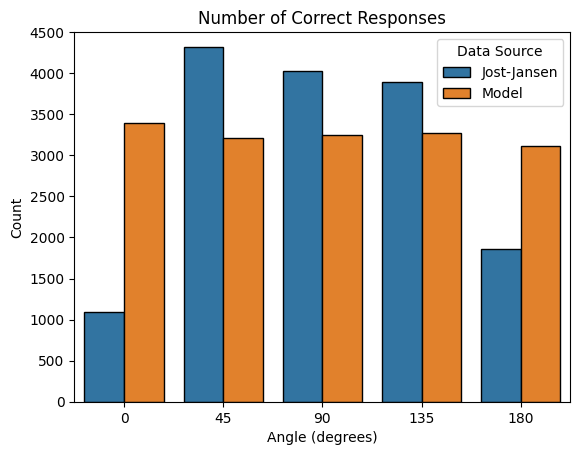

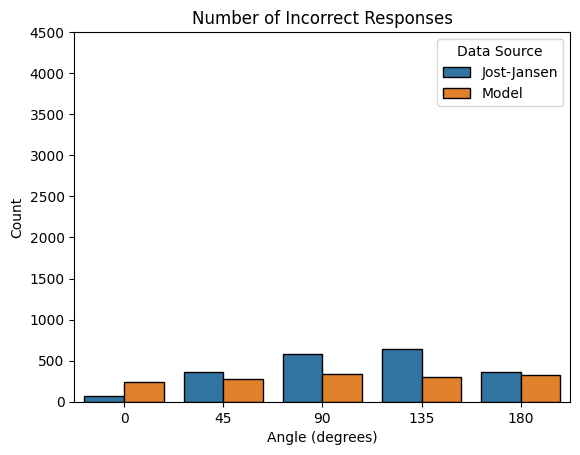

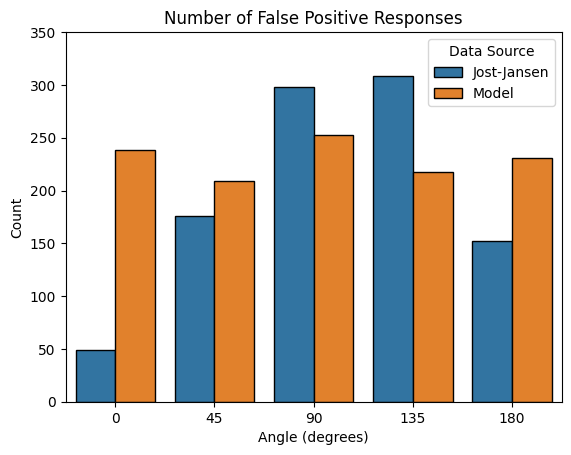

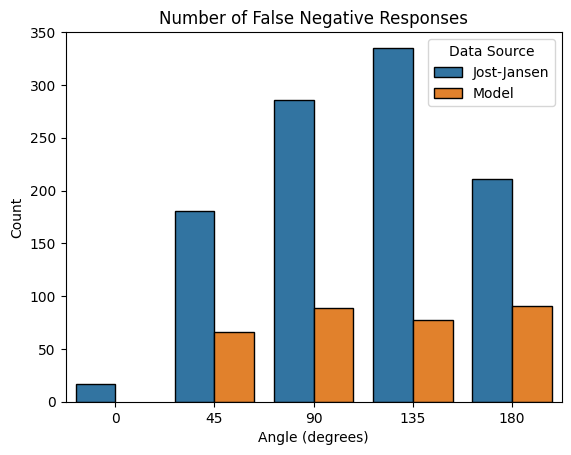


Model incorrect: 1472
Model incorrect % : 0.08309342365227208
JJ incorrect: 2013
JJ incorrect % : 0.11710977951015183

Model false positives: 1149
Model false positives %: 0.7805706521739131
Model total trials: 17715

JJ false positives: 983
JJ false positives %: 0.4883258817685047
JJ total trials: 17189
Model false negatives: 323
JJ false negatives: 1030


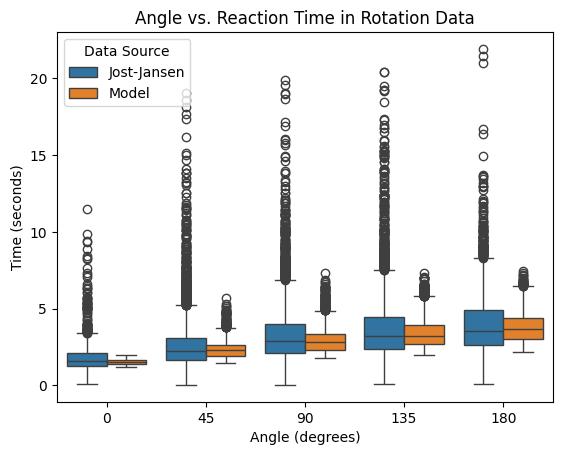

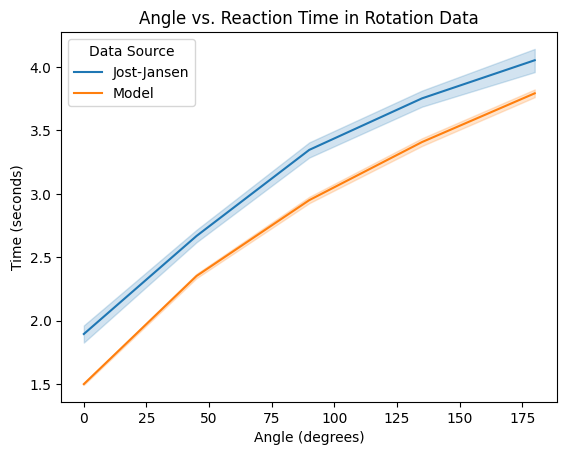


Model angle slope + intercept: 79.51382293935696 deg/s, with intercept of 1.6692195441762454 s
Jost+Jansen angle slope + intercept: 86.64362510142841 deg/s, with intercept of 2.1642868442643346 s

RMSE: 0.3462100454952852 s
MAE: 0.34241738126026006 s
R squared: 0.9714597146926638

PearsonRResult(statistic=0.9986664622575699, pvalue=5.8446018860789404e-05)
                          Mixed Linear Model Regression Results
Model:                        MixedLM           Dependent Variable:           time       
No. Observations:             34904             Method:                       REML       
No. Groups:                   81                Scale:                        1.3896     
Min. group size:              157               Log-Likelihood:               -55572.0470
Max. group size:              689               Converged:                    Yes        
Mean group size:              430.9                                                      
-------------------------------------

In [13]:

#
#           Jost + Jansen Analysis
#

# mean + error count
mean_just_model_jj = df_just_model_jj['time'].mean()
sd_just_model_jj = df_just_model_jj['time'].std()
mean_jj = df_just_jj['time'].mean()
sd_jj = df_just_jj['time'].std()

print("Model mean RT: " + str(mean_just_model_jj) + " s")
print("Model sd: " + str(sd_just_model_jj) + " s")
print("Jost+Jansen mean RT: " + str(mean_jj) + " s")
print("Jost+Jansen sd: " + str(sd_jj) + " s")



sns.countplot(data=df_jj_model_combined_graphing[df_jj_model_combined_graphing['correct'] == 1], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of Correct Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,4500)
plt.show()

sns.countplot(data=df_jj_model_combined_graphing[df_jj_model_combined_graphing['correct'] == 0], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of Incorrect Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,4500)
plt.show()

sns.countplot(data=df_jj_model_combined_graphing[df_jj_model_combined_graphing['false_positive'] == 1], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of False Positive Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,350)
plt.show()

sns.countplot(data=df_jj_model_combined_graphing[df_jj_model_combined_graphing['false_negative'] == 1], x="angle", hue="source", edgecolor="black", linewidth=1)
plt.legend(title="Data Source")
plt.title("Number of False Negative Responses")
plt.xlabel("Angle (degrees)")
plt.ylabel("Count")
plt.ylim(0,350)
plt.show()


df_model_incorrect = df_just_model_jj[df_just_model_jj['correct'] == 0]
df_jj_incorrect = df_just_jj[df_just_jj['correct'] == 0]

print()
print("Model incorrect: " + str(len(df_model_incorrect)))
print("Model incorrect % : " + str(len(df_model_incorrect)/len(df_just_model_jj)))
print("JJ incorrect: " + str(len(df_jj_incorrect)))
print("JJ incorrect % : " + str(len(df_jj_incorrect)/len(df_just_jj)))

print()
print("Model false positives: " + str(df_just_model_jj['false_positive'].value_counts().get(1, 0)))
print("Model false positives %: " + str(df_just_model_jj['false_positive'].value_counts().get(1, 0)/len(df_model_incorrect)))
print("Model total trials: " + str(len(df_just_model_jj)))

print()
print("JJ false positives: " + str(df_just_jj['false_positive'].value_counts().get(1, 0)))
print("JJ false positives %: " + str(df_just_jj['false_positive'].value_counts().get(1, 0)/len(df_jj_incorrect)))
print("JJ total trials: " + str(len(df_just_jj)))

print("Model false negatives: " + str(df_just_model_jj['false_negative'].value_counts().get(1, 0)))
print("JJ false negatives: " + str(df_just_jj['false_negative'].value_counts().get(1, 0)))

# intercept + rotation rate
sns.boxplot(data=df_jj_model_combined_graphing, x="angle", y="time", hue="source")
plt.legend(title="Data Source")
plt.title("Angle vs. Reaction Time in Rotation Data")
plt.xlabel("Angle (degrees)")
plt.ylabel("Time (seconds)")
plt.show()

sns.lineplot(data=df_jj_model_combined_graphing, x="angle", y="time", hue="source")
plt.legend(title="Data Source")
plt.title("Angle vs. Reaction Time in Rotation Data")
plt.xlabel("Angle (degrees)")
plt.ylabel("Time (seconds)")
plt.show()

m1, b1 = np.polyfit(x=df_just_model_jj['angle'], y=df_just_model_jj['time'], deg=1)
m2, b2 = np.polyfit(x=df_just_jj['angle'], y=df_just_jj['time'], deg=1)

print()
print("Model angle slope + intercept: " + str(1/m1) + " deg/s, with intercept of " + str(b1) + " s")
print("Jost+Jansen angle slope + intercept: " + str(1/m2) + " deg/s, with intercept of " + str(b2) + " s")


# rmse and mae
model_angles = df_jj_model_combined['angle'].unique()
model_angles.sort()

model_means = []
jj_means = []
for angle in model_angles:

    # correct answers
    model_means.append(df_just_model_jj[df_just_model_jj['angle'] == angle]['time'].mean())
    jj_means.append(df_just_jj[df_just_jj['angle'] == angle]['time'].mean())

print()
rmse = np.sqrt(np.mean((np.array(jj_means) - np.array(model_means)) ** 2))
print("RMSE: " + str(rmse) + " s")
mae = np.mean(np.abs(np.array(jj_means) - np.array(model_means)))                       # did mae too cause there's a lot of outliers
print("MAE: " + str(mae) + " s")

r_squared = 1 - (rmse/sd_jj)**2
print("R squared: " + str(r_squared))

# correlation
print()
print(stats.pearsonr(model_means, jj_means))

# mixed effects test:
model = smf.mixedlm(
    "time ~ angle * axis * source + angle * source * expected_answer + angle * source * correct",       # predicting reaction time from angle/source
    data=df_jj_model_combined,
    groups=df_jj_model_combined["subject_num"]           # random effect
)

result = model.fit()
print(result.summary())

Overlapping Coefficient: 0.8708
Overlapping Coefficient: 0.6888


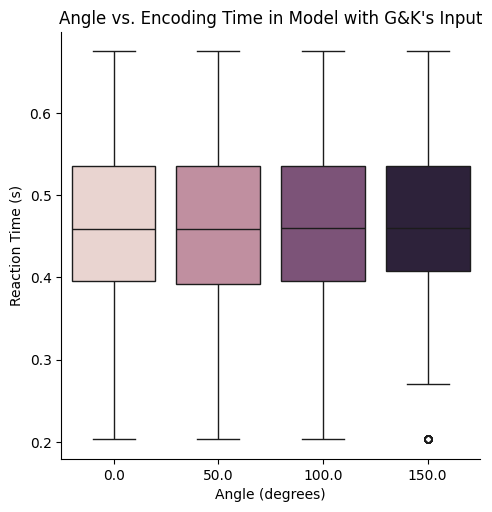

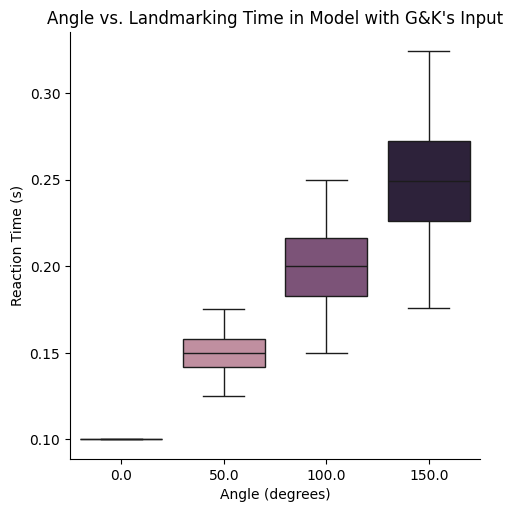

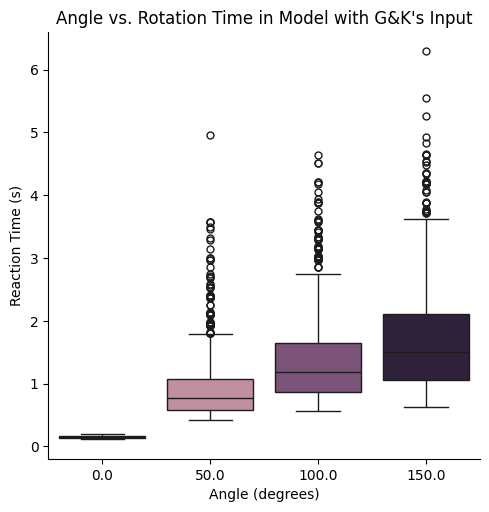

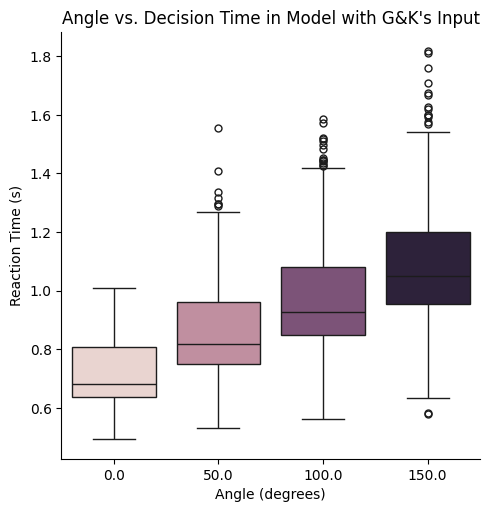


encoding slope: 76172.60266959472 deg/s
landmarking slope: 998.2218528130664 deg/s
rotation slope: 105.66880674710328 deg/s
decision slope: 475.7483101678508 deg/s

encoding slope: 1.312807971571599e-05 s/deg
landmarking slope: 0.0010017813146265258 s/deg
rotation slope: 0.009463530731385053 s/deg
decision slope: 0.0021019517644680352 s/deg

encoding intercept: 0.4595150960992843 s
landmarking intercept: 0.09983823264573477 s
rotation intercept: 0.3051941961849587 s
decision intercept: 0.7383796758911179 s


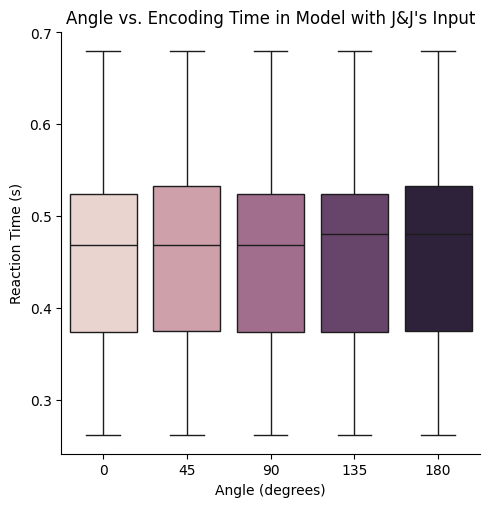

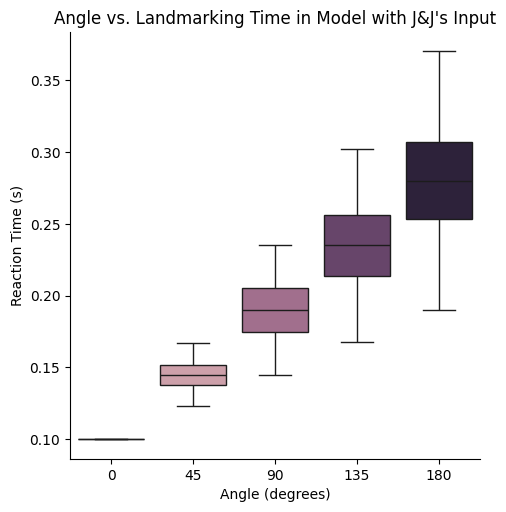

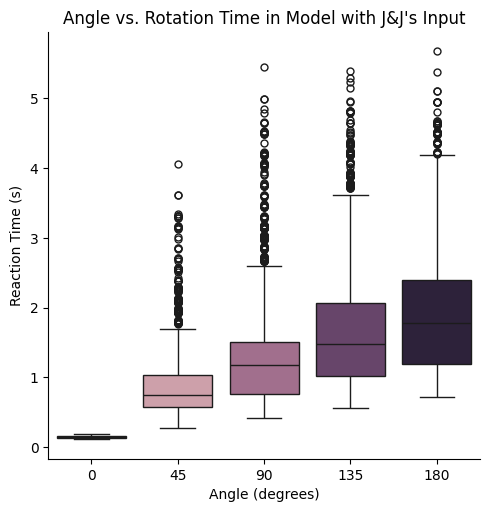

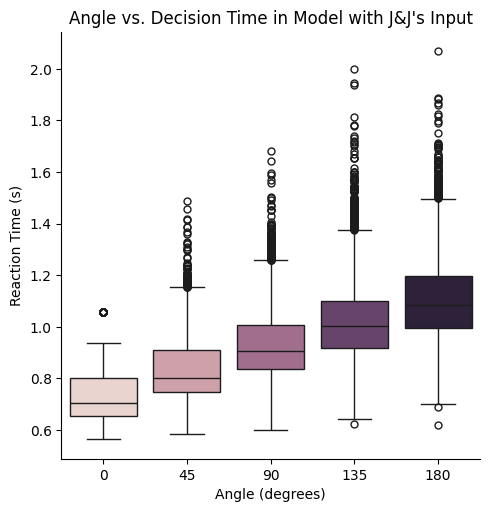

In [23]:
# 
#           BONUS ANALYSIS
#

# distribution overlaps
dist1 = stats.norm(loc=mean_gk, scale=sd_gk)
dist2 = stats.norm(loc=mean_just_model_gk, scale=sd_just_model_gk)

def overlap_pdf(x):
    return np.minimum(dist1.pdf(x), dist2.pdf(x))

# 3. Integrate over the shared domain (-infinity to infinity)
# Note: For bounded distributions (e.g., Beta), set actual bounds instead of np.inf
ovl_area, _ = quad(overlap_pdf, -np.inf, np.inf)

print(f"Overlapping Coefficient: {ovl_area:.4f}")

# distribution overlaps
dist1 = stats.norm(loc=mean_jj, scale=sd_jj)
dist2 = stats.norm(loc=mean_just_model_jj, scale=sd_just_model_jj)

def overlap_pdf(x):
    return np.minimum(dist1.pdf(x), dist2.pdf(x))

# 3. Integrate over the shared domain (-infinity to infinity)
# Note: For bounded distributions (e.g., Beta), set actual bounds instead of np.inf
ovl_area, _ = quad(overlap_pdf, -np.inf, np.inf)

print(f"Overlapping Coefficient: {ovl_area:.4f}")


# edit times in graphs rip

time_type_dict = {"angle": [], "time": [], "time_type": []}

for index, row in df_just_model_gk.iterrows():

    for col_name in ["encoding_time", "landmarking_time", "rotation_time", "decision_time"]:
        time_type_dict["angle"].append(row['angle'])
        time_type_dict['time'].append(row[col_name])
        time_type_dict['time_type'].append(col_name)

df_time_type = pd.DataFrame(time_type_dict)


sns.catplot(data=df_time_type[df_time_type['time_type'] == 'encoding_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Encoding Time in Model with G&K's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'landmarking_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Landmarking Time in Model with G&K's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'rotation_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Rotation Time in Model with G&K's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'decision_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Decision Time in Model with G&K's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

# m1, b1 = np.polyfit(x=df_just_model_gk['angle'], y=df_just_model_gk['encoding_time'], deg=1)
# m2, b2 = np.polyfit(x=df_just_model_gk['angle'], y=df_just_model_gk['landmarking_time'], deg=1)
# m3, b3 = np.polyfit(x=df_just_model_gk['angle'], y=df_just_model_gk['rotation_time'], deg=1)
# m4, b4 = np.polyfit(x=df_just_model_gk['angle'], y=df_just_model_gk['decision_time'], deg=1)
# m5, b5 = np.polyfit(x=df_just_model_gk['angle'], y=df_just_model_gk['time'], deg=1)
m1, b1 = np.polyfit(x=df_just_model_jj['angle'], y=df_just_model_jj['encoding_time'], deg=1)
m2, b2 = np.polyfit(x=df_just_model_jj['angle'], y=df_just_model_jj['landmarking_time'], deg=1)
m3, b3 = np.polyfit(x=df_just_model_jj['angle'], y=df_just_model_jj['rotation_time'], deg=1)
m4, b4 = np.polyfit(x=df_just_model_jj['angle'], y=df_just_model_jj['decision_time'], deg=1)
m5, b5 = np.polyfit(x=df_just_model_jj['angle'], y=df_just_model_jj['time'], deg=1)

print()
print("encoding slope: " + str(1/m1) + " deg/s")
print("landmarking slope: " + str(1/m2) + " deg/s")
print("rotation slope: " + str(1/m3) + " deg/s")
print("decision slope: " + str(1/m4) + " deg/s")

print()
print("encoding slope: " + str(m1) + " s/deg")
print("landmarking slope: " + str(m2) + " s/deg")
print("rotation slope: " + str(m3) + " s/deg")
print("decision slope: " + str(m4) + " s/deg")

print()
print("encoding intercept: " + str(b1) + " s")
print("landmarking intercept: " + str(b2) + " s")
print("rotation intercept: " + str(b3) + " s")
print("decision intercept: " + str(b4) + " s")


# JOST and Jansen data
time_type_dict = {"angle": [], "time": [], "time_type": []}

for index, row in df_just_model_jj.iterrows():

    for col_name in ["encoding_time", "landmarking_time", "rotation_time", "decision_time"]:
        time_type_dict["angle"].append(row['angle'])
        time_type_dict['time'].append(row[col_name])
        time_type_dict['time_type'].append(col_name)

df_time_type = pd.DataFrame(time_type_dict)
# df_time_type['time_type'] = df_time_type['time_type'].map({
#     "encoding_time": "Encoding Time",
#     "landmarking_time": "Landmarking Time",
#     "rotation_time": "Rotation Time",
#     "decision_time": "Decision Time"
# })

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'encoding_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Encoding Time in Model with J&J's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'landmarking_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Landmarking Time in Model with J&J's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'rotation_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Rotation Time in Model with J&J's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()

sns.catplot(data=df_time_type[df_time_type['time_type'] == 'decision_time'], kind='box', x='angle', y='time', hue="angle", legend=False)
plt.title("Angle vs. Decision Time in Model with J&J's Input")
plt.xlabel("Angle (degrees)")
plt.ylabel("Reaction Time (s)")
plt.show()




# g = sns.catplot(data=df_time_type, kind='box', x='angle', y='time', col='time_type', hue="angle", legend=False, col_wrap=2, height=5, aspect=1.5)
# g.set_axis_labels("Angle (degrees)", "Reaction Time (s)")
# g.set_titles("{col_name}")
# g.figure.suptitle("Angular Disparity vs. Reaction Time in Mental Rotation Stages", y=1.05, fontsize=16)
# plt.show()


# # bonus: gender differences
# sns.boxplot(data=df_model, x="Gender", y="Run Time (s)", hue="Gender", palette=["pink", "lightblue"])
# plt.show()
# sns.boxplot(data=df_gk, x="gender", y="time", hue="gender", palette=["pink", "lightblue"])
# plt.show()

# # gender vs. run time
# sns.boxplot(data=df_model, x="Gender", y="Run Time (s)", hue="Gender", palette=["pink", "lightblue"])
# plt.show()
# sns.lmplot(data=df_model, x="Rotation Angle (degrees)", y="Run Time (s)", hue="Gender")
# plt.show()
# sns.lmplot(data=df_model, x="Rotation Angle (degrees)", y="Rotation Time (s)", hue="Gender")
# plt.show()